
# Example of MRI response functions

Within this example we are going to plot the hemodynamic response function
(:term:`HRF`) model in :term:`SPM` together with the :term:`HRF` shape
proposed by G.Glover, as well as
their time and dispersion derivatives.
We also illustrate how users can input a custom response function,
which can for instance be useful when dealing with non human primate data
acquired using a contrast agent. In our case, we input a custom response
function for MION, a common
[agent](https://en.wikipedia.org/wiki/MRI_contrast_agent) used to
enhance contrast on MRI images of monkeys.

The :term:`HRF` is the filter which couples neural responses to the
metabolic-related changes in the MRI signal. :term:`HRF` models
are simply phenomenological.

In current analysis frameworks, the choice of :term:`HRF` model is essentially
left to the user. Fortunately, using the :term:`SPM` or
Glover model does not make a huge
difference. Adding derivatives should be considered whenever timing
information has some degree of uncertainty, and is actually useful to detect
timing issues.

This example requires matplotlib and scipy.


## Define stimulus parameters and response models

To get an impulse response, we simulate a single event occurring at time t=0,
with duration 1s.



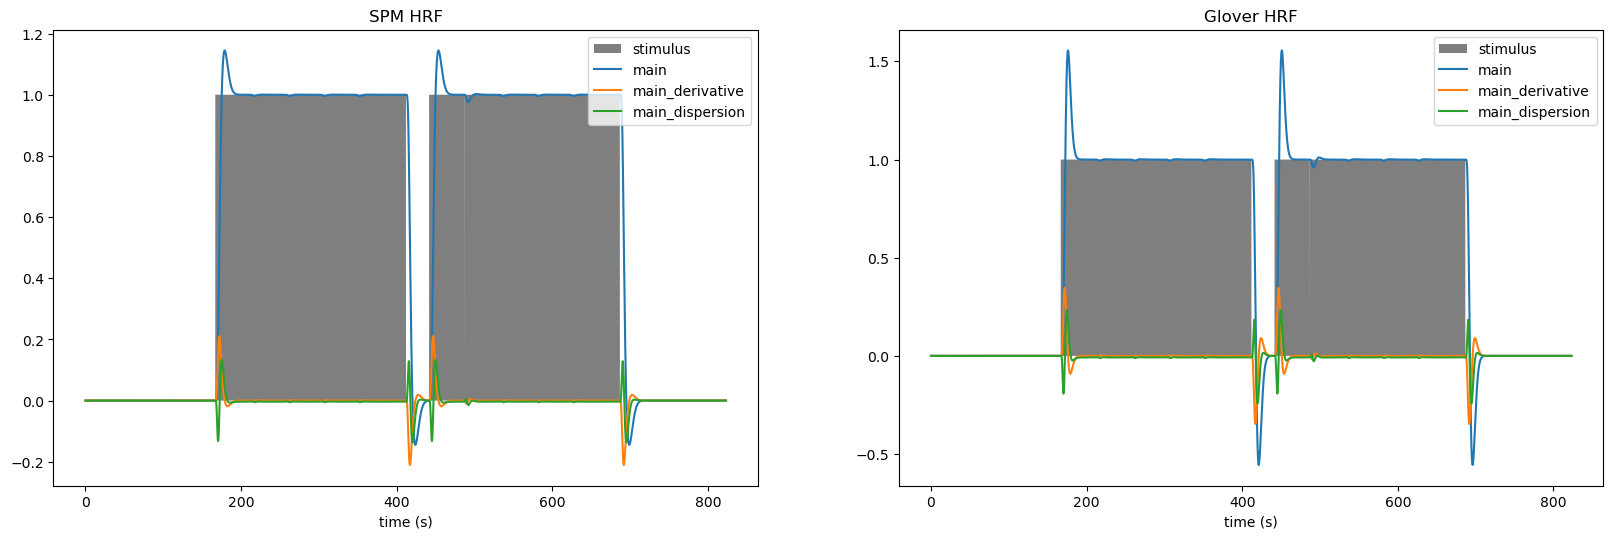

In [2]:
from nilearn._utils.helpers import check_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nilearn.glm.first_level import compute_regressor

events = pd.read_csv(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\events.csv")
design_matrix = pd.read_csv(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\design_matrix.csv")
GLM_estimates = pd.read_csv(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\GLM_estimates.csv")
haemo_values = pd.read_csv(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\haemo.csv")
short_channel_haemo = pd.read_csv(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\short_channel_haemo.csv")
design_matrix = design_matrix.rename(columns={design_matrix.columns[0]: "frame_times"})
time_length = design_matrix["frame_times"].values[-1]
frame_times = design_matrix["frame_times"].values
onset, amplitude, duration = events["onset"], np.ones(len(events["onset"])), events["duration"].values
exp_condition = np.array((onset, duration, amplitude)).reshape(3, len(onset))
stim = np.zeros_like(frame_times)
for i in range(len(onset)):
    mask = (frame_times >= onset.iloc[i]) & (frame_times < onset.iloc[i] + duration[i])
    stim[mask] = amplitude[i]
    rf_models = [
    ("spm + derivative + dispersion", "SPM HRF", None),
    ("glover + derivative + dispersion", "Glover HRF", None),
]

oversampling = 16

fig = plt.figure(figsize=(20, 6))
for i, (rf_model, model_title, labels) in enumerate(rf_models):
    # compute signal of interest by convolution
    signal, _labels = compute_regressor(
        exp_condition,
        rf_model,
        frame_times,
        con_id="main",
        oversampling=oversampling,
    )

    # plot signal
    plt.subplot(1, len(rf_models), i + 1)
    plt.fill(frame_times, stim, "k", alpha=0.5, label="stimulus")
    for j in range(signal.shape[1]):
        plt.plot(
            frame_times,
            signal.T[j],
            label=(
                labels[j]
                if labels is not None
                else (_labels[j] if _labels is not None else None)
            ),
        )
    plt.xlabel("time (s)")
    plt.legend(loc=1)
    plt.title(model_title)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.show()

Define response function models to be displayed:



In [254]:
events

,Unnamed: 0,trial_type,onset,duration
0,0,Control,24.969216,15.000000
1,1,Control,54.951936,15.000000
2,2,Control,84.934656,15.000000
3,3,Control,115.015680,15.000000
4,4,Control,157.483008,15.000000
5,5,n,172.523520,49.658158
6,6,Control,263.651328,15.000000
7,7,n,278.691840,61.507965
8,8,Control,356.450304,15.000000
9,9,n,371.490816,61.114019


In [6]:
GLM_estimates["Condition"].values

array(['Control', 'Control_derivative', 'Hard', 'Hard_derivative', 'Math',
       'Math_derivative', 'S1_D8 hbo', 'S1_D8 hbr', 'S2_D9 hbo',
       'S2_D9 hbr', 'S3_D10 hbo', 'S3_D10 hbr', 'S4_D11 hbo',
       'S4_D11 hbr', 'S5_D12 hbo', 'S5_D12 hbr', 'S6_D13 hbo',
       'S6_D13 hbr', 'S7_D14 hbo', 'S7_D14 hbr', 'S8_D15 hbo',
       'S8_D15 hbr', 'constant', 'drift_1', 'drift_10', 'drift_11',
       'drift_12', 'drift_13', 'drift_14', 'drift_15', 'drift_16',
       'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7',
       'drift_8', 'drift_9'], dtype=object)

Reconstruction check: True


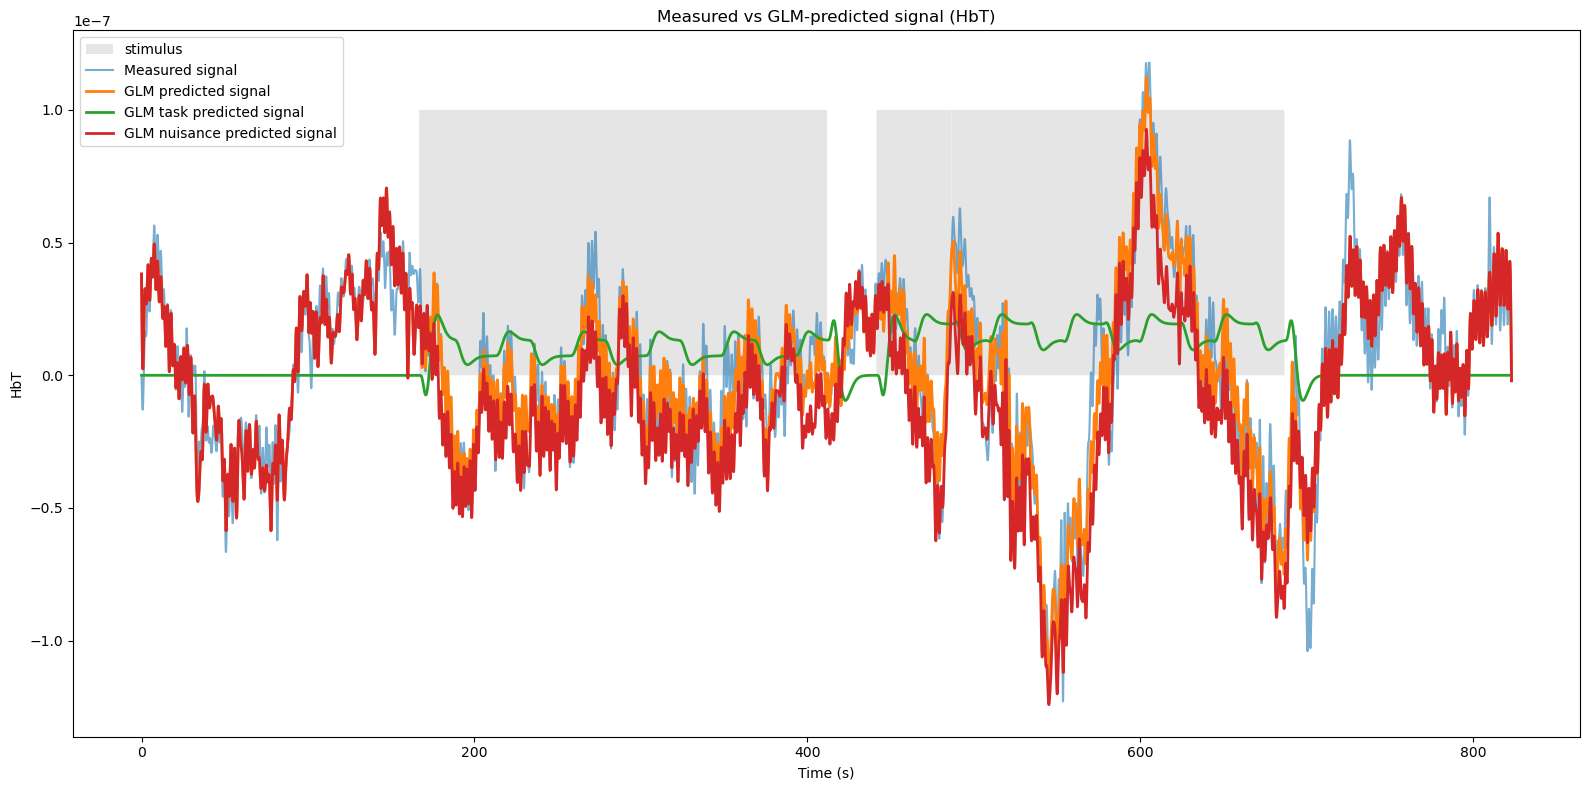

In [8]:
# Get design matrix columns (excluding frame_times)
design_cols = design_matrix.columns[1:].tolist()

y = haemo_values[haemo_values.columns[2:]].to_numpy().T.reshape(-1,)
# Reorder betas to match design matrix column order
betas = GLM_estimates.set_index("Condition").loc[design_cols, "theta"].to_numpy()
design_matrix_values = design_matrix[design_cols].to_numpy()
reconstructed_signal = design_matrix_values @ betas

# Now for task and nuisance - also using proper ordering
# task_cols = ['Control', 'Control_derivative', 'n', 'n_derivative']
task_cols = ['Control', 'Control_derivative', 'Hard', 'Hard_derivative', 'Math',
       'Math_derivative']
task_thetas = GLM_estimates.set_index("Condition").loc[task_cols, "theta"].to_numpy()
task_design_matrix = design_matrix[task_cols].to_numpy()
y_hat_task = task_design_matrix @ task_thetas

nuisance_cols = [col for col in design_cols if col not in task_cols]
nuisance_regressors_thetas = GLM_estimates.set_index("Condition").loc[nuisance_cols, "theta"].to_numpy()
nuisance_design_matrix = design_matrix[nuisance_cols].to_numpy()
y_hat_nuisance = nuisance_design_matrix @ nuisance_regressors_thetas

# Verification
print(f"Reconstruction check: {np.allclose(reconstructed_signal, y_hat_task + y_hat_nuisance)}")

plt.figure(figsize=(16, 8))
plt.fill(frame_times, stim*10**(-7), "k", alpha=0.1, label="stimulus")
plt.plot(frame_times, y, label="Measured signal", alpha=0.6)
plt.plot(frame_times, reconstructed_signal, label="GLM predicted signal", linewidth=2)
plt.plot(frame_times, y_hat_task, label="GLM task predicted signal", linewidth=2)
plt.plot(frame_times, y_hat_nuisance, label="GLM nuisance predicted signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("HbT")
plt.legend()
plt.title(f"Measured vs GLM-predicted signal (HbT)")
plt.tight_layout()
plt.savefig(rf"C:\Users\NTres\OneDrive - Danmarks Tekniske Universitet\Bachelor_projekt\Defense\Follow_up_results\Study_2\Measured_vs_GLM_predicted_signal_HbT.png")

In [230]:
y_hat_task

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -4.59967454e-09, -4.43811803e-09, -4.27819896e-09], shape=(5422,))

In [251]:
# Double check the reconstruction
print(f"y range: {y.min()*10**(6):.6f} to {y.max()*10**(6):6f}")
print(f"reconstructed_signal range: {reconstructed_signal.min()*10**(6):.6f} to {reconstructed_signal.max()*10**(6):.6f}")
print(f"y_hat_task range: {y_hat_task.min()*10**(6):.6f} to {y_hat_task.max()*10**(6):.6f}")
print(f"y_hat_nuisance range: {y_hat_nuisance.min()*10**(6):.6f} to {y_hat_nuisance.max()*10**(6):.6f}")

# Check if reconstruction is close to measured
print(f"\nCorrelation between y and reconstructed: {np.corrcoef(y, reconstructed_signal)[0,1]:.4f}")
print(f"R² (variance explained): {1 - np.var(y - reconstructed_signal) / np.var(y):.4f}")

y range: -0.136231 to 0.104422
reconstructed_signal range: -0.024689 to 0.017858
y_hat_task range: -0.012604 to 0.017902
y_hat_nuisance range: -0.017524 to 0.006264

Correlation between y and reconstructed: 0.2365
R² (variance explained): 0.0554


In [225]:
# Check if there's any scaling information stored
print("GLM estimates columns:", GLM_estimates.columns.tolist())

# Check the constant term - this can give clues about centering
constant_beta = GLM_estimates[GLM_estimates["Condition"] == "constant"]["theta"].values[0]
print(f"Constant beta: {constant_beta}")

# What's the mean of your current y?
print(f"Current y mean: {y.mean()}")

GLM estimates columns: ['Unnamed: 0', 'Condition', 'df', 'mse', 'p_value', 'se', 't', 'theta', 'Significant', 'ch_name']
Constant beta: -3.193088857444598e-09
Current y mean: 0.0007024898698914441


In [226]:
y

array([ 2.77105505e-17,  8.69662061e-03,  1.70886802e-02, ...,
        8.46517357e-03,  4.53015381e-03, -6.10045702e-18], shape=(5422,))